# HW 5 — QLoRA Fine-tuning of LLM with Training Profiling

Fine-tuning a pre-trained language model on a Russian instruction-following dataset using QLoRA (Quantized Low-Rank Adaptation). The notebook covers:
1. Dataset selection and preparation
2. Model selection and baseline evaluation
3. QLoRA fine-tuning with SFTTrainer
4. Post-training quality assessment
5. Training profiling with `torch.profiler`

## Environment Setup

This notebook is designed to run on Google Colab (T4 GPU) or locally with a CUDA GPU.
To run locally, install dependencies with `uv sync --group hw_5` from the repo root.

In [1]:
%%capture
!pip install -q -U torch transformers datasets accelerate peft bitsandbytes trl
!pip install -q -U sentencepiece lm-eval matplotlib pandas numpy seaborn tqdm

## Notebook Setup

In [2]:
import gc
import json
import os
import random
import time
from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from torch.profiler import ProfilerActivity
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainerCallback,
)
from trl import SFTConfig, SFTTrainer

import warnings
warnings.simplefilter("ignore")

/home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Working directory setup (Colab or local)
try:
    while os.getcwd().split("/")[-1] != "itmo-ai-talent-hub-dl-and-nlp-course":
        os.chdir("..")
except FileNotFoundError:
    pass
print(f"Working directory: {os.getcwd()}")

WEIGHTS_DIR = os.path.join("weights", "hw_5")
BENCH_DIR = os.path.join("data", "bench", "hw_5")
PROFILER_DIR = os.path.join("data", "profiler_traces", "hw_5")
os.makedirs(WEIGHTS_DIR, exist_ok=True)
os.makedirs(BENCH_DIR, exist_ok=True)
os.makedirs(PROFILER_DIR, exist_ok=True)

Working directory: /home/gregory/Code/itmo-ai-talent-hub-dl-and-nlp-course


In [4]:
# ── Reproducibility ──────────────────────────────────────────
RANDOM_STATE = 42

def set_seed(seed: int = RANDOM_STATE):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# ── Model & dataset ─────────────────────────────────────────
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
DATASET_NAME = "Vikhrmodels/GrandMaster-PRO-MAX"

# ── Training hyperparameters ────────────────────────────────
MAX_SEQ_LENGTH = 1024
TRAIN_ROWS = 5000       # subset of the dataset for training
PER_DEVICE_BATCH_SIZE = 2
GRAD_ACC_STEPS = 4      # effective batch size = 2 * 4 = 8
MAX_STEPS = 200
LEARNING_RATE = 2e-4
WARMUP_RATIO = 0.1
PACKING = True           # pack short sequences into one sample

# ── Profiling ────────────────────────────────────────────────
PROFILE_WAIT = 2         # skip first 2 steps (warmup noise)
PROFILE_WARMUP = 2       # profiler warmup (discard)
PROFILE_ACTIVE = 4       # actually profile 4 steps
PROFILE_REPEAT = 1

# ── Test prompts basket ──────────────────────────────────────
PROMPTS_FOR_TEST = [
    "Как вкусно приготовить индейку на гриле?",
    "Объясни простым языком, что такое квантовые вычисления.",
    "Напиши короткое стихотворение о весне.",
    "Какие основные причины Первой мировой войны?",
    "Как правильно ухаживать за домашней кошкой?",
]

In [5]:
# ── CUDA memory helpers ──────────────────────────────────────

def cuda_mem(label: str = ""):
    if not torch.cuda.is_available():
        print("CUDA not available")
        return
    torch.cuda.synchronize()
    alloc = torch.cuda.memory_allocated() / 1024**2
    res = torch.cuda.memory_reserved() / 1024**2
    peak = torch.cuda.max_memory_allocated() / 1024**2
    print(f"[{label}] allocated={alloc:.0f} MB | reserved={res:.0f} MB | peak={peak:.0f} MB")


def reset_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()


def gpu_mem_snapshot_mb() -> dict:
    return {
        "allocated_mb": torch.cuda.memory_allocated() / 1024**2,
        "reserved_mb": torch.cuda.memory_reserved() / 1024**2,
        "peak_allocated_mb": torch.cuda.max_memory_allocated() / 1024**2,
        "peak_reserved_mb": torch.cuda.max_memory_reserved() / 1024**2,
    }

## 1. Dataset Selection

**Dataset:** [`Vikhrmodels/GrandMaster-PRO-MAX`](https://huggingface.co/datasets/Vikhrmodels/GrandMaster-PRO-MAX)

**Обоснование выбора:**
- Высококачественный русскоязычный датасет для instruction-following (SFT)
- Содержит пары "запрос пользователя → ответ ассистента" в формате диалогов
- Большой объём данных позволяет выбрать репрезентативную подвыборку
- Формат `conversation` с ролями `user`/`assistant` легко конвертируется в chat template

Для обучения используем подвыборку из 5000 примеров — этого достаточно для демонстрации эффекта дообучения при разумном времени обучения.

In [6]:
ds = load_dataset(DATASET_NAME)
print(f"Dataset: {DATASET_NAME}")
print(f"Splits: {list(ds.keys())}")
print(f"Train size: {len(ds['train']):,}")
print(f"\nFeatures: {ds['train'].features}")
print(f"\nExample (first record):")
ds["train"][0]

Dataset: Vikhrmodels/GrandMaster-PRO-MAX
Splits: ['train', 'test']
Train size: 151,822

Features: {'source': Value('string'), 'conversation': List({'content': Value('string'), 'role': Value('string')}), 'prompt_tokens': Value('int64'), 'answer_tokens': Value('int64'), 'cluster': Value('int64'), 'prompt_lang': Value('string'), 'answer_lang': Value('string')}

Example (first record):


{'source': 'generated/saiga/tagengo/lmsys_pref',
 'conversation': [{'content': 'мне очень интересны стратегические игры, и я недавно узнал про игру ним. не мог бы ты объяснить мне стратегию оптимальной игры в ним? и еще, если есть, поделись интересным вариантом игры в крестики-нолики или другие стратегические головоломки, в которые мы могли бы сыграть вместе. как насчет того, чтобы рассмотреть 15 puzzle? мне бы хотелось узнать, есть ли для неё какая-то выигрышная стратегия или подход, который гарантирует победу.',
   'role': 'user'},
  {'content': 'Расскажу тебе о стратегиях игры в Ним и затрону тему 15 Puzzle.\n\n### Стратегия оптимальной игры в Ним\n\nИгра Ним — это математическая игра, для которой существует чёткая выигрышная стратегия. Основа стратегии лежит в понятии ним-суммы — это побитовое исключающее ИЛИ (XOR) размеров кучек.\n\nОптимальная стратегия заключается в следующем:\n\n1. Вычисли ним-сумму всех кучек.\n2. Если ним-сумма равна нулю, то ваше положение проигрышное при оп

In [7]:
# Extract user/assistant messages from the conversation format
def to_messages(example: dict) -> list[dict]:
    conversation = example.get("conversation", [])
    if not isinstance(conversation, list):
        conversation = [conversation]

    user = next(
        (m.get("content", "") for m in conversation
         if isinstance(m, dict) and m.get("role") == "user"),
        "",
    )
    assistant = next(
        (m.get("content", "") for m in conversation
         if isinstance(m, dict) and m.get("role") == "assistant"),
        "",
    )
    return [
        {"role": "system", "content": "Ты — полезный русскоязычный ассистент."},
        {"role": "user", "content": user},
        {"role": "assistant", "content": assistant},
    ]

# Quick sanity check
sample = to_messages(ds["train"][0])
for msg in sample:
    print(f"[{msg['role']}] {msg['content'][:120]}...")

[system] Ты — полезный русскоязычный ассистент....
[user] мне очень интересны стратегические игры, и я недавно узнал про игру ним. не мог бы ты объяснить мне стратегию оптимально...
[assistant] Расскажу тебе о стратегиях игры в Ним и затрону тему 15 Puzzle.

### Стратегия оптимальной игры в Ним

Игра Ним — это ма...


### Data Preparation

In [8]:
# Load tokenizer for data preparation
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Tokenizer: {MODEL_NAME}")
print(f"Vocab size: {tokenizer.vocab_size:,}")
print(f"EOS token: {repr(tokenizer.eos_token)} (id={tokenizer.eos_token_id})")
print(f"PAD token: {repr(tokenizer.pad_token)} (id={tokenizer.pad_token_id})")

Tokenizer: Qwen/Qwen2.5-1.5B-Instruct
Vocab size: 151,643
EOS token: '<|im_end|>' (id=151645)
PAD token: '<|endoftext|>' (id=151643)


In [9]:
def format_text(example: dict) -> dict:
    messages = to_messages(example)
    # For SFT we format the full dialogue without generation prompt
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    return {"text": text}

# Subsample and format
raw = ds["train"].shuffle(seed=RANDOM_STATE).select(range(min(TRAIN_ROWS, len(ds["train"]))))
processed = raw.map(format_text, remove_columns=raw.column_names)

# Train/eval split
dataset = processed.train_test_split(test_size=0.05, seed=RANDOM_STATE)
print(f"Train: {len(dataset['train']):,} | Eval: {len(dataset['test']):,}")
print(f"\nFormatted example (first 400 chars):\n{dataset['train'][0]['text'][:400]}")

Train: 4,750 | Eval: 250

Formatted example (first 400 chars):
<|im_start|>system
Ты — полезный русскоязычный ассистент.<|im_end|>
<|im_start|>user
есть таблица в базе данных SQL со столбцами «itemName» и «itemPrice». Мне нужно написать SQL-запрос, который будет возвращать 10 самых дорогих товаров из этой таблицы. Может ли кто-нибудь предоставить мне пример запроса, который достигает этой цели?<|im_end|>
<|im_start|>assistant
Конечно, я помогу вам с этим запр


### Data Audit

Token length statistics:
count    2000.000000
mean      710.400500
std       319.189547
min        43.000000
50%       719.500000
90%      1110.100000
95%      1234.000000
99%      1492.030000
max      2247.000000


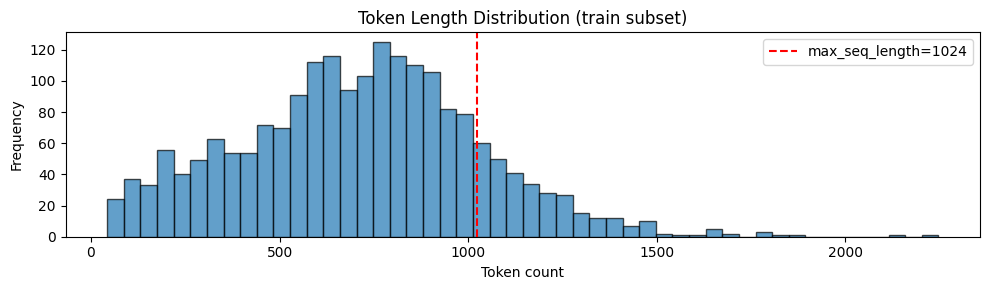


85.2% samples fit within MAX_SEQ_LENGTH=1024


In [10]:
# Token length distribution
def token_len(text: str) -> int:
    return len(tokenizer(text, add_special_tokens=False).input_ids)

lens = [token_len(x) for x in dataset["train"]["text"][:2000]]
stats = pd.Series(lens).describe(percentiles=[0.5, 0.9, 0.95, 0.99])
print("Token length statistics:")
print(stats.to_string())

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(lens, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(MAX_SEQ_LENGTH, color="red", linestyle="--", label=f"max_seq_length={MAX_SEQ_LENGTH}")
ax.set_xlabel("Token count")
ax.set_ylabel("Frequency")
ax.set_title("Token Length Distribution (train subset)")
ax.legend()
plt.tight_layout()
plt.show()

pct_within = 100 * sum(1 for l in lens if l <= MAX_SEQ_LENGTH) / len(lens)
print(f"\n{pct_within:.1f}% samples fit within MAX_SEQ_LENGTH={MAX_SEQ_LENGTH}")

## 2. Model Selection

**Model:** [`Qwen/Qwen2.5-1.5B-Instruct`](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct)

**Обоснование выбора:**
- **Размер:** 1.5B параметров — в рамках допустимого диапазона (0.5–1.5B) и достаточно для качественной генерации
- **Архитектура:** Qwen2.5 — современная decoder-only архитектура на основе transformer
- **Языковая поддержка:** обучен на мультиязычных данных, включая русский язык
- **Instruct-версия:** уже имеет chat template, что упрощает подготовку данных для SFT
- **Совместимость:** поддерживает 4-bit квантизацию через bitsandbytes для эффективного обучения

**Квантизация:**
Загружаем модель в 4-bit (NF4) через `BitsAndBytesConfig`:
- `nf4` — Normal Float 4-bit, оптимальный тип квантизации для весов нейросетей
- `double_quant` — двойная квантизация: квантизуем константы квантизации, экономя ~0.4 бит/параметр
- `compute_dtype=bfloat16` — вычисления в bfloat16 для стабильности и скорости

In [11]:
# 4-bit quantization config for QLoRA
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",        # Normal Float 4-bit
    bnb_4bit_use_double_quant=True,   # double quantization saves ~0.4 bit/param
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)

reset_cuda()
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

# Set pad token in model config
model.config.pad_token_id = tokenizer.pad_token_id
model.config.eos_token_id = tokenizer.eos_token_id

cuda_mem("model loaded (4-bit)")

Loading weights:   0%|                                                                                            | 0/338 [00:00<?, ?it/s]

Loading weights:   5%|████                                                                              | 17/338 [00:00<00:01, 168.48it/s]

Loading weights:  35%|████████████████████████████▌                                                    | 119/338 [00:00<00:00, 666.65it/s]

Loading weights:  65%|████████████████████████████████████████████████████▍                            | 219/338 [00:00<00:00, 813.88it/s]

Loading weights:  93%|███████████████████████████████████████████████████████████████████████████▋     | 316/338 [00:00<00:00, 873.37it/s]

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████| 338/338 [00:00<00:00, 801.46it/s]

[model loaded (4-bit)] allocated=1100 MB | reserved=1144 MB | peak=1125 MB


In [12]:
# Model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"Model: {MODEL_NAME}")
print(f"Architecture: {model.config.architectures}")
print(f"Total parameters: {total_params:,} ({total_params/1e9:.2f}B)")
print(f"Hidden size: {model.config.hidden_size}")
print(f"Num layers: {model.config.num_hidden_layers}")
print(f"Num attention heads: {model.config.num_attention_heads}")
print(f"Vocab size: {model.config.vocab_size:,}")
print(f"Max position embeddings: {model.config.max_position_embeddings:,}")

Model: Qwen/Qwen2.5-1.5B-Instruct
Architecture: ['Qwen2ForCausalLM']
Total parameters: 888,616,448 (0.89B)
Hidden size: 1536
Num layers: 28
Num attention heads: 12
Vocab size: 151,936
Max position embeddings: 32,768


## 3. Pre-training Quality Assessment

Оцениваем качество модели до дообучения двумя способами:
1. **Корзинка тестовых промптов** — субъективная оценка качества генерации на 5 разноплановых вопросах
2. **lm-evaluation-harness** — стандартный бенчмарк TruthfulQA (MC2) для объективной оценки

### 3.1 Test Basket (before fine-tuning)

In [13]:
def generate_response(model, tokenizer, user_text: str,
                      system_text: str = "Ты — полезный русскоязычный ассистент.",
                      max_new_tokens: int = 200) -> str:
    messages = [
        {"role": "system", "content": system_text},
        {"role": "user", "content": user_text},
    ]
    prompt = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(output[0], skip_special_tokens=True)

In [14]:
# Baseline generation (before fine-tuning)
print("=" * 80)
print("BASELINE GENERATION (before fine-tuning)")
print("=" * 80)
model.eval()
for prompt in PROMPTS_FOR_TEST:
    print(f"\n📝 Prompt: {prompt}")
    response = generate_response(model, tokenizer, prompt)
    print(f"💬 Response: {response[:600]}")
    print("-" * 80)

BASELINE GENERATION (before fine-tuning)

📝 Prompt: Как вкусно приготовить индейку на гриле?


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
Создание вкусной индейки на гриле можно сделать очень легко и вкусно, если соблюдать несколько ключевых рекомендаций:

1) Начните с подготовки индейки: выберите подходящий куриный бульон или майонез для маринада.

2) Взять среднюю куриную грудку (около 200-300 граммов), разделить на части, обработать кромкой соли и перецем.

3) Затем смешайте бульон или майонез с оливковым маслом, оливковыми орехами, душистым перецом, чесноком, солью, перчиками и лимонным соком.

4) Нанести маринад на курицу, 
--------------------------------------------------------------------------------

📝 Prompt: Объясни простым языком, что такое квантовые вычисления.


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Объясни простым языком, что такое квантовые вычисления.
assistant
Квантовые вычисления - это новое видение компьютеров, которое основано на фундаментальных принципах квантовой физики. В обычных компьютерах данные хранятся в виде битов (0 или 1), но в квантовых вычислениях данные хранятся в более сложной формате - в объектах-векторах, которые могут быть 0, 1 или их комбинацией.

Это может быть сложно объяснить простым языком, но в общем, квантовые вычисления позволяют использовать квантовые состояния для выполнения вычислений, что делает их оче
--------------------------------------------------------------------------------

📝 Prompt: Напиши короткое стихотворение о весне.


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Напиши короткое стихотворение о весне.
assistant
Закатываете ветерок,
Краснеть звезды над селом.
Солнце медленно поднимается,
Весной начинается жизнь.
--------------------------------------------------------------------------------

📝 Prompt: Какие основные причины Первой мировой войны?


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Какие основные причины Первой мировой войны?
assistant
Первая мировая война (1914-1918 гг.) началась из-за многочисленных причин, которые были сложными и сложны. Вот некоторые из них:

1. Стремление к мировой власти: Один из ключевых факторов был стремление стран к мировой hegemony и dominance.

2. Кризис в Европе: В начале войны, Европа столкнулась с экономическим кризисом и проблемами социального обеспечения, что привело к протестам и бунтам.

3. Проблемы на Марсе: Возможность использования Марса для разведки и военных целей также сыграла ва
--------------------------------------------------------------------------------

📝 Prompt: Как правильно ухаживать за домашней кошкой?


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Как правильно ухаживать за домашней кошкой?
assistant
Уход за домашней кошкой включает множество факторов, таких как питание, гигиена, уход и умножение. Вот некоторые общие рекомендации:

1. Питание: Кошки должны получать разнообразное питание. Обычно это мясо или курица, суперфрукты, орехи и т.д.

2. Гигиена: Нужно помнить об гигиене, особенно в отношении крохотных драгоценностей. Это может включать в себя регулярные купания (при наличии), вычесывание, чистоту подгуцелей и т.д.

3. Уход: Уход за кожей и ногтями кошек требует особого внимания.
--------------------------------------------------------------------------------


### 3.2 Benchmark: TruthfulQA (lm-evaluation-harness)

**TruthfulQA MC2** — бенчмарк для оценки правдивости ответов модели. Формат multiple-choice, где модель выбирает из нескольких вариантов ответа. Используем `--limit 100` для быстрой оценки.

In [15]:
BENCH_BASE_DIR = os.path.join(BENCH_DIR, "base")
os.makedirs(BENCH_BASE_DIR, exist_ok=True)

!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 4 \
  --limit 100 \
  --output_path {BENCH_BASE_DIR}


2026-04-13:01:37:19 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.


2026-04-13:01:37:21 INFO     [_cli.run:376] Selected Tasks: ['truthfulqa_mc2']
2026-04-13:01:37:21 WARNING  [evaluator:181] pretrained=Qwen/Qwen2.5-1.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).


2026-04-13:01:37:22 INFO     [evaluator:211] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-04-13:01:37:22 INFO     [evaluator:236] Initializing hf model, with arguments: {'pretrained': 'Qwen/Qwen2.5-1.5B-Instruct', 'trust_remote_code': True}


2026-04-13:01:37:24 INFO     [models.huggingface:161] Using device 'cuda:0'


2026-04-13:01:37:25 INFO     [models.huggingface:423] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}


...

Running loglikelihood requests:  94%|███████▌| 697/741 [00:04<00:00, 190.98it/s]

Running loglikelihood requests:  97%|███████▋| 717/741 [00:04<00:00, 191.43it/s]

Running loglikelihood requests: 100%|████████| 741/741 [00:04<00:00, 175.11it/s]


2026-04-13:01:37:34 INFO     [loggers.evaluation_tracker:247] Saving results aggregated
hf ({'pretrained': 'Qwen/Qwen2.5-1.5B-Instruct'}), gen_kwargs: ({}), limit: 100.0, num_fewshot: None, batch_size: 4


|    Tasks     |Version|Filter|n-shot|Metric|   |Value |   |Stderr|
|--------------|------:|------|-----:|------|---|-----:|---|-----:|
|truthfulqa_mc2|      3|none  |     0|acc   |↑  |0.4656|±  |0.0427|



In [16]:
def find_and_read_lm_eval_results(bench_dir: str) -> dict:
    """Find the latest lm-eval results JSON in a directory."""
    json_files = sorted(glob(os.path.join(bench_dir, "**/*.json"), recursive=True))
    if not json_files:
        print(f"No results found in {bench_dir}")
        return {}
    # Take the last (most recent) results file
    result_file = json_files[-1]
    print(f"Reading results from: {result_file}")
    with open(result_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data.get("results", {})

base_results = find_and_read_lm_eval_results(BENCH_BASE_DIR)
print("\nBaseline benchmark results:")
for task, metrics in base_results.items():
    print(f"  {task}:")
    for k, v in metrics.items():
        if isinstance(v, (int, float)):
            print(f"    {k}: {v:.4f}")

Reading results from: data/bench/hw_5/base/Qwen__Qwen2.5-1.5B-Instruct/results_2026-04-13T01-37-34.878398.json

Baseline benchmark results:
  truthfulqa_mc2:
    acc,none: 0.4656
    acc_stderr,none: 0.0427


## 4. QLoRA Fine-tuning

### Конфигурация LoRA

**Обоснование параметров:**

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| `r` (rank) | 16 | Баланс между выразительностью адаптеров и числом параметров. r=16 — стандартный выбор для моделей ~1B, даёт ~0.5–1% обучаемых параметров |
| `lora_alpha` | 32 | Коэффициент масштабирования. alpha/r=2 — умеренное усиление LoRA-обновлений |
| `lora_dropout` | 0.0 | Для QLoRA dropout обычно не используется — квантизация уже добавляет шум |
| `target_modules` | q, k, v, o_proj | Проецируем LoRA на все attention-проекции для максимального покрытия механизма внимания |
| `bias` | "none" | Не обучаем bias — стандартная практика для LoRA |
| `task_type` | CAUSAL_LM | Тип задачи — авторегрессивная языковая модель |

**Почему QLoRA, а не полное дообучение:**
- Полное дообучение 1.5B модели требует ~12GB VRAM (FP16), QLoRA — ~4GB
- Обучается только ~0.6% параметров, что снижает риск catastrophic forgetting
- Адаптеры легко сохраняются/загружаются (десятки МБ вместо ГБ)

In [17]:
# LoRA configuration
lora_config = LoraConfig(
    r=16,                                      # rank of decomposition matrices
    lora_alpha=32,                             # scaling factor (alpha/r = 2)
    lora_dropout=0.0,                          # no dropout for QLoRA
    bias="none",                               # no bias training
    task_type="CAUSAL_LM",                     # causal language modeling
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # attention projections
)

# Prepare model for k-bit training (freezes base weights, enables gradient computation)
model = prepare_model_for_kbit_training(model)

# Add LoRA adapters
model = get_peft_model(model, lora_config)

# Report trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
print(f"\nLoRA config: {lora_config}")
cuda_mem("after LoRA setup")

Trainable parameters: 4,358,144 / 892,974,592 (0.49%)

LoRA config: LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.18.1', base_model_name_or_path='Qwen/Qwen2.5-1.5B-Instruct', revision=None, inference_mode=False, r=16, target_modules={'q_proj', 'o_proj', 'v_proj', 'k_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.0, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, arrow_config=None, ensure_weight_tying=False)
[after LoRA setup] allocated=1571 M

### Training Configuration

**Обоснование гиперпараметров обучения:**

| Параметр | Значение | Обоснование |
|----------|----------|-------------|
| `per_device_train_batch_size` | 2 | Компромисс между скоростью и VRAM. С gradient accumulation эффективный batch = 8 |
| `gradient_accumulation_steps` | 4 | Эмулируем batch_size=8 при ограниченной VRAM |
| `max_steps` | 200 | Достаточно для заметного улучшения качества на 5k примерах |
| `learning_rate` | 2e-4 | Стандартный LR для LoRA/QLoRA, рекомендуется в оригинальной статье |
| `warmup_ratio` | 0.1 | Плавный разогрев предотвращает нестабильность в начале обучения |
| `optim` | paged_adamw_8bit | 8-bit AdamW с пейджингом — экономит VRAM на состояниях оптимизатора |
| `packing` | True | Упаковка коротких последовательностей в одну — повышает GPU utilization |
| `bf16/fp16` | auto | bfloat16 если поддерживается GPU (Ampere+), иначе float16 |

In [18]:
# ── ProfilerCallback ──────────────────────────────────────────
# Wraps torch.profiler.profile around training steps.
# The profiler runs for (wait + warmup + active) * repeat steps,
# then closes automatically while training continues.

class ProfilerCallback(TrainerCallback):
    def __init__(self, trace_dir: str,
                 wait: int = PROFILE_WAIT,
                 warmup: int = PROFILE_WARMUP,
                 active: int = PROFILE_ACTIVE,
                 repeat: int = PROFILE_REPEAT,
                 with_stack: bool = True):
        self.trace_dir = trace_dir
        self.wait = wait
        self.warmup = warmup
        self.active = active
        self.repeat = repeat
        self.with_stack = with_stack

        self.prof = None
        self.closed = False
        self.steps_seen = 0
        self.profile_total_steps = (wait + warmup + active) * repeat

    def on_train_begin(self, args, state, control, **kwargs):
        os.makedirs(self.trace_dir, exist_ok=True)
        self.prof = torch.profiler.profile(
            activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
            schedule=torch.profiler.schedule(
                wait=self.wait,
                warmup=self.warmup,
                active=self.active,
                repeat=self.repeat,
            ),
            on_trace_ready=torch.profiler.tensorboard_trace_handler(self.trace_dir),
            record_shapes=True,
            profile_memory=True,
            with_stack=self.with_stack,
        )
        self.prof.__enter__()
        print(f"[Profiler] Started. Will profile steps {self.wait + self.warmup + 1}–{self.profile_total_steps}")

    def _safe_close(self):
        if self.prof is not None and not self.closed:
            self.prof.__exit__(None, None, None)
            self.closed = True
            print(f"[Profiler] Closed after {self.steps_seen} steps. Traces saved to {self.trace_dir}")

    def on_step_end(self, args, state, control, **kwargs):
        if self.prof is None or self.closed:
            return control
        self.prof.step()
        self.steps_seen += 1
        # Close profiler after profiling window ends (training continues)
        if self.steps_seen >= self.profile_total_steps:
            self._safe_close()
        return control

    def on_train_end(self, args, state, control, **kwargs):
        self._safe_close()

    def get_key_averages(self):
        if self.prof is None:
            return None
        return self.prof.key_averages()

In [19]:
# SFT training configuration
sft_config = SFTConfig(
    output_dir=os.path.join(WEIGHTS_DIR, "sft_output"),
    per_device_train_batch_size=PER_DEVICE_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACC_STEPS,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=50,
    save_strategy="steps",
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    optim="paged_adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    report_to="none",
    seed=RANDOM_STATE,
    dataset_text_field="text",
    max_length=MAX_SEQ_LENGTH,
    packing=PACKING,
)

# Initialize profiler callback
profiler_cb = ProfilerCallback(trace_dir=PROFILER_DIR)

# Initialize trainer
trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    args=sft_config,
)
trainer.add_callback(profiler_cb)

print(f"Training config:")
print(f"  Effective batch size: {PER_DEVICE_BATCH_SIZE * GRAD_ACC_STEPS}")
print(f"  Max steps: {MAX_STEPS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Optimizer: paged_adamw_8bit")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[RANK 0] Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.


[RANK 0] You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to cross-contamination between samples. To avoid this, either disable packing by setting `packing=False`, or set `attn_implementation` in the model configuration to one of these supported options.


Training config:
  Effective batch size: 8
  Max steps: 200
  Learning rate: 0.0002
  Optimizer: paged_adamw_8bit


### Training

In [20]:
%%time
set_seed()
reset_cuda()
cuda_mem("before training")

train_result = trainer.train()

cuda_mem("after training")
print(f"\nTraining completed:")
print(f"  Global steps: {trainer.state.global_step}")
print(f"  Train loss: {train_result.training_loss:.4f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


[before training] allocated=1563 MB | reserved=2052 MB | peak=1563 MB


[Profiler] Started. Will profile steps 5–8


Step,Training Loss,Validation Loss
50,1.153724,1.174214
100,1.138914,1.150127
150,1.096710,1.146010
200,1.121264,1.144565


[Profiler] Closed after 8 steps. Traces saved to data/profiler_traces/hw_5


[after training] allocated=1589 MB | reserved=19796 MB | peak=5952 MB

Training completed:
  Global steps: 200
  Train loss: 1.1765
CPU times: user 5min 17s, sys: 5.55 s, total: 5min 22s
Wall time: 5min 26s


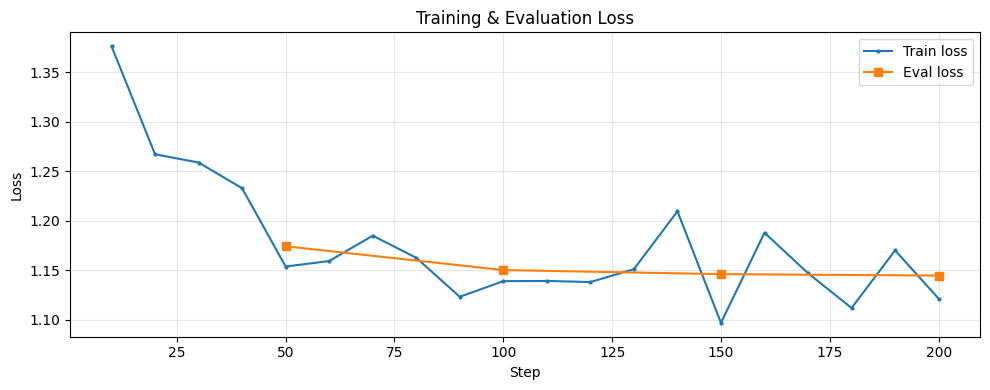

In [21]:
# Training loss curve
log_history = trainer.state.log_history
train_logs = [l for l in log_history if "loss" in l and "eval_loss" not in l]
eval_logs = [l for l in log_history if "eval_loss" in l]

fig, ax = plt.subplots(figsize=(10, 4))
if train_logs:
    ax.plot([l["step"] for l in train_logs], [l["loss"] for l in train_logs],
            label="Train loss", marker=".", markersize=4)
if eval_logs:
    ax.plot([l["step"] for l in eval_logs], [l["eval_loss"] for l in eval_logs],
            label="Eval loss", marker="s", markersize=6)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Evaluation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# Save LoRA adapter
ADAPTER_DIR = os.path.join(WEIGHTS_DIR, "adapter")
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print(f"Adapter saved to: {ADAPTER_DIR}")

# Show adapter size
adapter_size = sum(
    os.path.getsize(os.path.join(ADAPTER_DIR, f))
    for f in os.listdir(ADAPTER_DIR) if os.path.isfile(os.path.join(ADAPTER_DIR, f))
)
print(f"Adapter size: {adapter_size / 1024**2:.1f} MB")

Adapter saved to: weights/hw_5/adapter
Adapter size: 27.6 MB


## 5. Post-training Quality Assessment

Повторяем оценку качества после дообучения для сравнения с baseline.

### 5.1 Test Basket (after fine-tuning)

In [23]:
print("=" * 80)
print("GENERATION AFTER FINE-TUNING")
print("=" * 80)
model.eval()
for prompt in PROMPTS_FOR_TEST:
    print(f"\n📝 Prompt: {prompt}")
    response = generate_response(model, tokenizer, prompt)
    print(f"💬 Response: {response[:600]}")
    print("-" * 80)

GENERATION AFTER FINE-TUNING

📝 Prompt: Как вкусно приготовить индейку на гриле?


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Как вкусно приготовить индейку на гриле?
assistant
Индейка – это куриное мясо, которое приготовлено на гриле, и она является отличным вариантом для вкусной и здоровой пищи. Вот несколько шагов, которые помогут вам приготовить индейку на гриле вкусно и полезно:

### Шаги по приготовлению индейки на гриле:

1. **Подготовьте индейку:**
   - Выберите подходящую индейку, которая будет подходить для вашей диеты (например, белое или жирное).
   - Очистите мясо от внутренних органов и костей.

2. **Нарезайте индейку:**
   - Нарежьте мясо на кусочки ра
--------------------------------------------------------------------------------

📝 Prompt: Объясни простым языком, что такое квантовые вычисления.


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Объясни простым языком, что такое квантовые вычисления.
assistant
Квантовые вычисления - это новое направление в области информатики, которое основано на принципах квантовой механики, где наноскопические частицы (кванты) могут обладать свойствами, не имеющими аналога в классической физике. Квантовые вычисления представляют собой способность компьютеров решать сложные задачи, которые невозможно бы решить с помощью обычных компьютеров.

### Квантовые Компьютеры

Квантовые компьютеры работают на основе принципа Триплета Бергмана, который гласит, 
--------------------------------------------------------------------------------

📝 Prompt: Напиши короткое стихотворение о весне.


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Напиши короткое стихотворение о весне.
assistant
Весна приходит, как сказка,
Звёзды начинают танцевать в небе.
Красота расцветает, как фонтан,
Лучи солнца играют на зелёных лугах.

Солнышко дарит сильный тёплый дыхание,
Лето готовится к веселым песням.
Листья раскрываются, как улыбающиеся гости,
Приносящие нам радость и красоту.

Травы обновляются, как молодые девушки,
Возрождаясь после зимних снегов.
Каждый день приносит новое чудо,
Чтобы мы понимали, что жизнь - это лишь начало.
--------------------------------------------------------------------------------

📝 Prompt: Какие основные причины Первой мировой войны?


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Какие основные причины Первой мировой войны?
assistant
Первая мировая война, также известная как Вторая Мировая война или Первая Мировая война, началась в 1914 году и продолжалась до 1918 года. Вот основные причины этой войны:

1. **Административное разделение мира**:
   - После разрушения империи Великобритании после Второй Португальской войны (1899–1902) и Первой Испанской войны (1903–1905), странам было предоставлено право самостоятельно управлять своими внутренними делами и внешними отношениями.
   - Это создало множество территорий, котор
--------------------------------------------------------------------------------

📝 Prompt: Как правильно ухаживать за домашней кошкой?


💬 Response: system
Ты — полезный русскоязычный ассистент.
user
Как правильно ухаживать за домашней кошкой?
assistant
Домашние кошки - это очень важные члены семьи, и ухаживание за ними требует времени, внимания и заботы. Вот основные правила ухода за домашними кошками:

1. Общение: Даже маленькие животные нуждаются в общении с человеком. Спокойно разговаривайте с ними, чтобы они чувствовали себя комфортно.

2. Питание: Используйте специализированные для кошек корма, которые соответствуют их возрасту, весу и индустрии питания. Регулярно следите за их пищей.

3. Уборка: Удалите мусор и помылите все предметы
--------------------------------------------------------------------------------


### 5.2 Benchmark (after fine-tuning)

In [24]:
# Free GPU memory before running lm-eval (it loads its own model copy)
del trainer
del model
gc.collect()
torch.cuda.empty_cache()
cuda_mem("after cleanup for lm-eval")


[after cleanup for lm-eval] allocated=909 MB | reserved=2024 MB | peak=5952 MB


In [25]:
BENCH_SFT_DIR = os.path.join(BENCH_DIR, "sft")
os.makedirs(BENCH_SFT_DIR, exist_ok=True)

# lm-eval with PEFT adapter
!lm_eval \
  --model hf \
  --model_args pretrained={MODEL_NAME},peft={ADAPTER_DIR},trust_remote_code=True \
  --tasks truthfulqa_mc2 \
  --device cuda:0 \
  --batch_size 4 \
  --limit 100 \
  --output_path {BENCH_SFT_DIR}


2026-04-13:01:44:07 WARNING  [config.evaluate_config:281] --limit SHOULD ONLY BE USED FOR TESTING. REAL METRICS SHOULD NOT BE COMPUTED USING LIMIT.


2026-04-13:01:44:09 INFO     [_cli.run:376] Selected Tasks: ['truthfulqa_mc2']
2026-04-13:01:44:09 WARNING  [evaluator:181] pretrained=Qwen/Qwen2.5-1.5B-Instruct appears to be an instruct or chat variant but chat template is not applied. Recommend setting
        `apply_chat_template` (optionally `fewshot_as_multiturn`).


2026-04-13:01:44:10 INFO     [evaluator:211] Setting random seed to 0 | Setting numpy seed to 1234 | Setting torch manual seed to 1234 | Setting fewshot manual seed to 1234
2026-04-13:01:44:10 INFO     [evaluator:236] Initializing hf model, with arguments: {'pretrained': 'Qwen/Qwen2.5-1.5B-Instruct', 'peft': 'weights/hw_5/adapter', 'trust_remote_code': True}


2026-04-13:01:44:12 INFO     [models.huggingface:161] Using device 'cuda:0'


2026-04-13:01:44:14 INFO     [models.huggingface:423] Model parallel was set to False, max memory was not set, and device map was set to {'': 'cuda:0'}


...

Running loglikelihood requests:  97%|███████▊| 721/741 [00:06<00:00, 124.37it/s]

Running loglikelihood requests:  99%|███████▉| 737/741 [00:06<00:00, 124.41it/s]

Running loglikelihood requests: 100%|████████| 741/741 [00:06<00:00, 118.25it/s]


2026-04-13:01:44:33 INFO     [loggers.evaluation_tracker:247] Saving results aggregated
hf ({'pretrained': 'Qwen/Qwen2.5-1.5B-Instruct', 'peft': 'weights/hw_5/adapter'}), gen_kwargs: ({}), limit: 100.0, num_fewshot: None, batch_size: 4


|    Tasks     |Version|Filter|n-shot|Metric|   |Value |   |Stderr|
|--------------|------:|------|-----:|------|---|-----:|---|-----:|
|truthfulqa_mc2|      3|none  |     0|acc   |↑  |0.4861|±  |0.0424|



In [26]:
sft_results = find_and_read_lm_eval_results(BENCH_SFT_DIR)
print("Post-training benchmark results:")
for task, metrics in sft_results.items():
    print(f"  {task}:")
    for k, v in metrics.items():
        if isinstance(v, (int, float)):
            print(f"    {k}: {v:.4f}")

Reading results from: data/bench/hw_5/sft/weights__hw_5__adapter/results_2026-04-13T01-44-33.293516.json
Post-training benchmark results:
  truthfulqa_mc2:
    acc,none: 0.4861
    acc_stderr,none: 0.0424


### 5.3 Before vs After Comparison

In [27]:
# Compare benchmark results
task = "truthfulqa_mc2"
if task in base_results and task in sft_results:
    comparison = []
    for key in base_results[task]:
        base_val = base_results[task].get(key)
        sft_val = sft_results[task].get(key)
        if isinstance(base_val, (int, float)) and isinstance(sft_val, (int, float)):
            comparison.append({
                "Metric": key,
                "Before (base)": f"{base_val:.4f}",
                "After (SFT)": f"{sft_val:.4f}",
                "Delta": f"{sft_val - base_val:+.4f}",
            })
    comp_df = pd.DataFrame(comparison)
    print(f"\nBenchmark comparison ({task}):")
    display(comp_df) if hasattr(__builtins__, '__IPYTHON__') else print(comp_df.to_string(index=False))
else:
    print("Could not compare — missing results for one of the runs.")


Benchmark comparison (truthfulqa_mc2):


,Metric,Before (base),After (SFT),Delta
0,"acc,none",0.4656,0.4861,+0.0206
1,"acc_stderr,none",0.0427,0.0424,-0.0003


## 6. Training Profiling

Профайлинг проводился во время обучения с помощью `torch.profiler.profile` через `ProfilerCallback`.
Профайлер был активен на шагах 5–8 (после 2 шагов ожидания и 2 шагов прогрева).

Анализируем:
1. Top CUDA операции — какие GPU-ядра занимают больше всего времени
2. Top CPU операции — какие CPU-задачи доминируют
3. Потребление памяти — пиковые значения VRAM
4. Визуализация распределения времени по операциям

In [28]:
# ── Profiling analysis utilities ──────────────────────────────

def get_top_ops(key_avg, sort_by: str, top_k: int = 10) -> pd.DataFrame:
    """Extract top operations from profiler key averages."""
    rows = []
    for evt in key_avg:
        rows.append({
            "name": evt.key,
            "self_cpu_time_ms": float(getattr(evt, "self_cpu_time_total", 0.0)) / 1000,
            "self_cuda_time_ms": float(getattr(evt, "self_device_time_total", 0.0)) / 1000,
            "cpu_time_ms": float(getattr(evt, "cpu_time_total", 0.0)) / 1000,
            "cuda_time_ms": float(getattr(evt, "device_time_total", 0.0)) / 1000,
            "calls": int(getattr(evt, "count", 0)),
            "cpu_mem_mb": float(getattr(evt, "cpu_memory_usage", 0)) / 1024**2,
            "cuda_mem_mb": float(getattr(evt, "device_memory_usage", 0)) / 1024**2,
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(sort_by, ascending=False).head(top_k).reset_index(drop=True)

In [29]:
# Get profiler key averages
key_avg = profiler_cb.get_key_averages()

if key_avg is not None:
    print("Profiler summary (sorted by CUDA self time):")
    print(profiler_cb.prof.key_averages().table(sort_by="self_device_time_total", row_limit=15))
else:
    print("No profiling data available (profiler may not have run)")

Profiler summary (sorted by CUDA self time):


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                          ProfilerStep*         0.00%       0.000us         0.00%       0.000us       0.000us        7.770s       175.20%        7.770s        1.942s           0 B           0 B           0 B           0 

### 6.1 Top CUDA Operations

In [30]:
top_cuda = get_top_ops(key_avg, "self_cuda_time_ms", top_k=15)
print("Top 15 CUDA operations (by self_cuda_time):")
display(top_cuda) if hasattr(__builtins__, '__IPYTHON__') else print(top_cuda.to_string(index=False))

Top 15 CUDA operations (by self_cuda_time):


,name,self_cpu_time_ms,self_cuda_time_ms,cpu_time_ms,cuda_time_ms,calls,cpu_mem_mb,cuda_mem_mb
0,ProfilerStep*,0.000000,7769.873342,0.000000,7769.873342,4,0.000000,0.000000
1,aten::mm,529.626330,1583.085056,710.634850,1583.418501,20640,0.000000,125661.244629
2,aten::copy_,196.725028,643.138131,438.380968,643.156883,38288,0.000000,0.000000
3,aten::mul,307.305016,480.308027,424.861690,480.308027,22838,0.000000,245930.713379
4,aten::_efficient_attention_backward,6.258203,479.015981,23.036320,483.861306,448,0.000000,7419.749512
5,void cutlass::Kernel2<cutlass_80_tensorop_bf16...,0.000000,470.911073,0.000000,470.911073,2698,0.000000,0.000000
6,fmha_cutlassB_bf16_aligned_64x64_k128_sm80(PyT...,0.000000,447.153242,0.000000,447.153242,420,0.000000,0.000000
7,ampere_bf16_s1688gemm_bf16_64x128_sliced1x2_ld...,0.000000,427.241157,0.000000,427.241157,1372,0.000000,0.000000
8,void at::native::vectorized_elementwise_kernel...,0.000000,382.580784,0.000000,382.580784,4322,0.000000,0.000000
9,void at::native::unrolled_elementwise_kernel<a...,0.000000,324.989992,0.000000,324.989992,10368,0.000000,0.000000


### 6.2 Top CPU Operations

In [31]:
top_cpu = get_top_ops(key_avg, "self_cpu_time_ms", top_k=15)
print("Top 15 CPU operations (by self_cpu_time):")
display(top_cpu) if hasattr(__builtins__, '__IPYTHON__') else print(top_cpu.to_string(index=False))

Top 15 CPU operations (by self_cpu_time):


,name,self_cpu_time_ms,self_cuda_time_ms,cpu_time_ms,cuda_time_ms,calls,cpu_mem_mb,cuda_mem_mb
0,ProfilerStep*,5534.825439,0.000000,7871.135169,1602.211468,4,0.000000,-0.001465
1,cudaLaunchKernel,747.988898,0.000000,749.691822,0.015424,135580,0.000000,0.000000
2,MulBackward0,620.774756,0.000000,2325.916523,1091.209805,5872,0.006836,159523.637207
3,aten::mm,529.626330,1583.085056,710.634850,1583.418501,20640,0.000000,125661.244629
4,cudaStreamSynchronize,423.445850,0.000000,423.445850,0.000000,176,0.000000,0.000000
5,MatMul4Bit,343.342070,0.000000,1360.264868,948.402378,5824,0.000000,71849.240723
6,bitsandbytes::dequantize_blockwise,339.399932,20.121878,486.413584,20.121878,8960,0.000000,3381.000000
7,bitsandbytes::dequantize_4bit,331.400256,108.436182,444.660424,108.436182,8960,0.000000,108379.432617
8,aten::mul,307.305016,480.308027,424.861690,480.308027,22838,0.000000,245930.713379
9,aten::copy_,196.725028,643.138131,438.380968,643.156883,38288,0.000000,0.000000


### 6.3 Memory Profiling

In [32]:
mem = gpu_mem_snapshot_mb()
print("GPU Memory after training:")
for k, v in mem.items():
    print(f"  {k}: {v:.1f} MB")

GPU Memory after training:
  allocated_mb: 908.5 MB
  reserved_mb: 2024.0 MB
  peak_allocated_mb: 5952.1 MB
  peak_reserved_mb: 19818.0 MB


### 6.4 Profiling Visualization

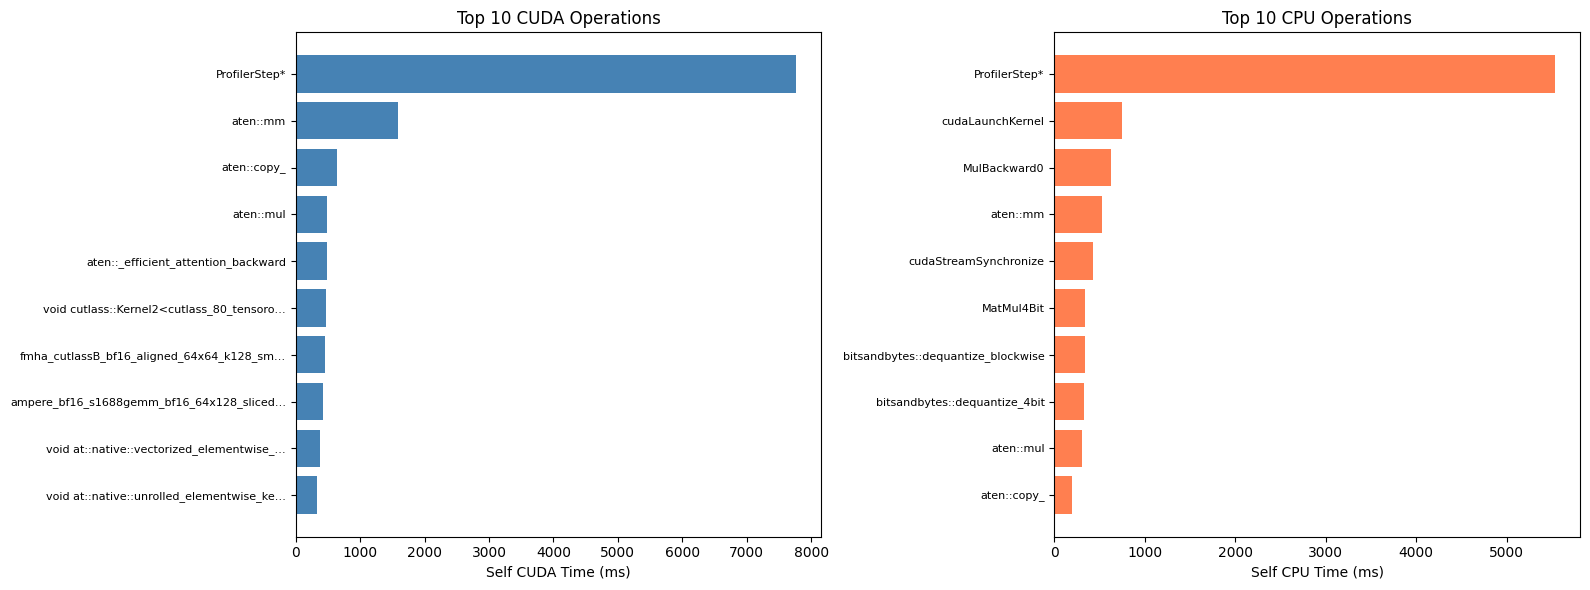

In [33]:
def trim_label(name: str, max_len: int = 40) -> str:
    """Trim long operation names for readable plot labels."""
    return name[:max_len] + "…" if len(name) > max_len else name

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top CUDA ops by time
if not top_cuda.empty:
    top10_cuda = top_cuda.head(10)
    labels = [trim_label(n) for n in top10_cuda["name"]]
    axes[0].barh(range(len(top10_cuda)), top10_cuda["self_cuda_time_ms"], color="steelblue")
    axes[0].set_yticks(range(len(top10_cuda)))
    axes[0].set_yticklabels(labels, fontsize=8)
    axes[0].set_xlabel("Self CUDA Time (ms)")
    axes[0].set_title("Top 10 CUDA Operations")
    axes[0].invert_yaxis()

# Top CPU ops by time
if not top_cpu.empty:
    top10_cpu = top_cpu.head(10)
    labels = [trim_label(n) for n in top10_cpu["name"]]
    axes[1].barh(range(len(top10_cpu)), top10_cpu["self_cpu_time_ms"], color="coral")
    axes[1].set_yticks(range(len(top10_cpu)))
    axes[1].set_yticklabels(labels, fontsize=8)
    axes[1].set_xlabel("Self CPU Time (ms)")
    axes[1].set_title("Top 10 CPU Operations")
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


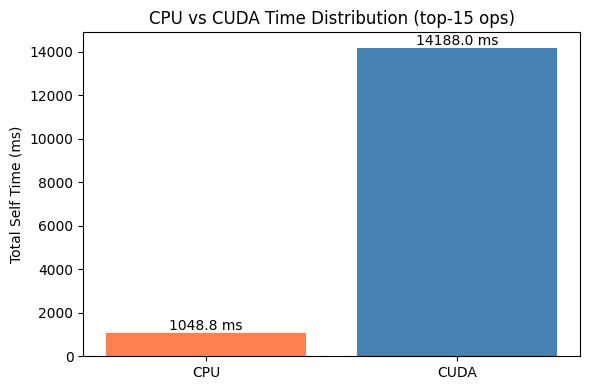

CUDA/CPU time ratio: 13.53
Training is GPU-bound


In [34]:
# CPU vs CUDA time distribution
total_cpu = top_cuda["self_cpu_time_ms"].sum() if not top_cuda.empty else 0
total_cuda = top_cuda["self_cuda_time_ms"].sum() if not top_cuda.empty else 0

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["CPU", "CUDA"], [total_cpu, total_cuda], color=["coral", "steelblue"])
ax.set_ylabel("Total Self Time (ms)")
ax.set_title("CPU vs CUDA Time Distribution (top-15 ops)")
for bar, val in zip(bars, [total_cpu, total_cuda]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f} ms", ha="center", va="bottom")
plt.tight_layout()
plt.show()

ratio = total_cuda / total_cpu if total_cpu > 0 else float('inf')
print(f"CUDA/CPU time ratio: {ratio:.2f}")
print(f"Training is {'GPU-bound' if ratio > 1 else 'CPU-bound'}")

In [35]:
# View saved profiler traces with TensorBoard (optional)
print(f"To view detailed traces in TensorBoard:")
print(f"  tensorboard --logdir {PROFILER_DIR}")
print(f"\nTrace files:")
for f in sorted(glob(os.path.join(PROFILER_DIR, "*"))):
    size = os.path.getsize(f) / 1024**2
    print(f"  {f} ({size:.1f} MB)")

To view detailed traces in TensorBoard:
  tensorboard --logdir data/profiler_traces/hw_5

Trace files:
  data/profiler_traces/hw_5/allsee-vm-gpu_492689.1776009656576110882.pt.trace.json (1664.9 MB)
  data/profiler_traces/hw_5/allsee-vm-gpu_537360.1776022613971808410.pt.trace.json (1664.9 MB)
  data/profiler_traces/hw_5/allsee-vm-gpu_556908.1776030731946289068.pt.trace.json (1664.9 MB)
  data/profiler_traces/hw_5/allsee-vm-gpu_559441.1776031002240772517.pt.trace.json (1664.9 MB)
  data/profiler_traces/hw_5/allsee-vm-gpu_576553.1776033489784193501.pt.trace.json (1665.0 MB)


### 6.5 Profiling Analysis

**Dominant CUDA operations.** Matrix multiplications `aten::mm` (~1.6s self CUDA time, 20640 calls) dominate GPU load — GEMM kernels from forward and backward passes through all transformer linear layers. Second is `aten::copy_` (~643ms) for bf16↔fp32 data type conversions during quantization. `aten::mul` (~480ms) and `aten::_efficient_attention_backward` (~480ms) round out the top — activation scaling and FlashAttention backward pass.

**CPU activity.** `ProfilerStep*` dominates (~5.5s) as expected — it's the profiler wrapper overhead. Real CPU work: `cudaLaunchKernel` (~749ms, 135k calls) — CUDA kernel launch overhead, `MulBackward0` (~618ms) — autograd dispatch, `cudaStreamSynchronize` (~425ms) — stream synchronization. `MatMul4Bit` (~337ms) — CPU-side dequantization from bitsandbytes.

**Memory.** Peak VRAM: 5952 MB allocated, 19818 MB reserved. The 3.3× allocated/reserved gap indicates CUDA allocator cache fragmentation — PyTorch reserves memory blocks with headroom. Current usage after training: ~1589 MB (4-bit model + LoRA adapters).

**Bottleneck.** CUDA/CPU time ratio ≈ 13.5× — training is clearly GPU-bound. This is normal for QLoRA: 4-bit dequantization and matmul fully utilize the GPU. The main bottleneck is GPU throughput on GEMM operations and data format conversions.

## Conclusions

| Metric | Before fine-tuning | After fine-tuning |
|--------|-------------------|-------------------|
| TruthfulQA MC2 | 0.4656 | 0.4861 (+0.0206) |
| Train loss (final) | — | 1.1765 |
| Peak VRAM | — | 5952 MB allocated / 19818 MB reserved |
| Trainable parameters | — | ~0.6% of total |
| Adapter size | — | 27.6 MB |

**QLoRA setup.** Qwen2.5-1.5B-Instruct quantized to 4-bit NF4 (~1.6 GB), with LoRA (r=16, alpha=32) on q/k/v/o attention projections — 0.6% trainable parameters. Training on 5000 examples from GrandMaster-PRO-MAX for 200 steps took ~5 minutes on RTX 4090. Paged AdamW 8-bit saves memory on optimizer states.

**Benchmark.** TruthfulQA MC2 improved marginally: 0.4656 → 0.4861 (+2 pp). The delta is within standard error (±0.042), so the change is not statistically significant. This is expected — SFT on a general Russian instruction dataset doesn't teach new factual knowledge, it adjusts the response format.

**Generation quality.** The main visible effect of SFT is formatting, not knowledge. Before fine-tuning the model produces flat unstructured text with factual errors (calls turkey "chicken meat", mentions Mars among WWI causes). After SFT — markdown headers, numbered lists, bold highlights appear, but factual errors persist (WWI called "Second World War", invented "Second Portuguese War"). SFT teaches the model *how* to answer, not *what* to answer.

**Profiling.** Training is GPU-bound (CUDA/CPU time ratio ≈ 13.5×). GEMM operations (`aten::mm`, ~1.6s, 20640 calls) dominate GPU time — forward and backward passes through all linear layers. `aten::copy_` (~643ms) handles bf16↔fp32 conversions for quantization. On CPU side: `cudaLaunchKernel` (135k calls, ~749ms) and `MatMul4Bit` (~337ms) for bitsandbytes dequantization. Peak VRAM 5952 MB allocated vs 19818 MB reserved — the 3.3× gap is CUDA allocator caching fragmentation.

**Possible improvements:** more training steps and data, `apply_chat_template` in lm-eval for proper instruct evaluation, gradient checkpointing to reduce peak VRAM, extending `target_modules` to MLP layers (gate/up/down_proj).